# **EDA Notebook**

In [140]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt 
import seaborn as sns

In [ ]:
#Import parquet into dataframe

file_path = Path("data") / "processed" / "data_final.parquet"

df = pd.read_parquet(file_path)

df.head()

,Facility ID,Facility Name,Address,City/Town,State,ZIP Code,County/Parish,Telephone Number,Hospital Type,Hospital Ownership,...,birth_friendly_YES,birth_friendly_MISSING,MORT_fac_rate,MORT_bet_rate,Safety_fac_rate,Safety_bet_rate,READM_fac_rate,READM_bet_rate,PtExp_fac_rate,TE_fac_rate
0,10001,southeast health medical center,1108 ross clark circle,dothan,al,36301,houston,(334) 793-8701,acute care hospitals,government - hospital district or authority,...,True,False,1.000000,0.0,0.875,0.428571,1.000000,0.0,1.0,0.916667
1,10005,marshall medical centers,2505 u s highway 431 north,boaz,al,35957,marshall,(256) 593-8310,acute care hospitals,government - hospital district or authority,...,True,False,0.857143,0.0,0.875,0.000000,0.818182,0.0,1.0,1.000000
2,10006,north alabama medical center,1701 veterans drive,florence,al,35630,lauderdale,(256) 768-8400,acute care hospitals,proprietary,...,True,False,1.000000,0.0,1.000,0.375000,0.818182,0.0,1.0,0.833333
3,10007,mizell memorial hospital,702 n main st,opp,al,36467,covington,(334) 493-3541,acute care hospitals,voluntary non-profit - private,...,False,True,0.428571,0.0,0.375,0.000000,0.636364,0.0,1.0,0.583333
4,10008,crenshaw community hospital,101 hospital circle,luverne,al,36049,crenshaw,(334) 335-3374,acute care hospitals,proprietary,...,False,True,0.142857,0.0,NaN,NaN,0.181818,0.0,NaN,0.500000


In [142]:
#Explore basic properties of dataset columns

print(f"The total number of facilities is {len(df['Facility ID'])}.\n")
print(f"The number of unique facilities is {len(df['Facility ID'].unique())}.\n")
print(f"Do duplicate entries exist?: {len(df['Facility ID'])!=len(df['Facility ID'].unique())}\n")
print(f"Count of NAs:\n\n{df.isna().sum()}")

The total number of facilities is 5426.

The number of unique facilities is 5426.

Do duplicate entries exist?: False

Count of NAs:

Facility ID                                            0
Facility Name                                          0
Address                                                0
City/Town                                              0
State                                                  0
ZIP Code                                               0
County/Parish                                          0
Telephone Number                                       0
Hospital Type                                          0
Hospital Ownership                                     0
Emergency Services                                     0
Meets criteria for birthing friendly designation    3161
Hospital overall rating                             2560
Hospital overall rating footnote                    2854
MORT Group Measure Count                             875
Count of Fa

In [144]:
#Explore descriptive statistics of dataset columns

print(df.describe())

       Hospital overall rating  MORT Group Measure Count  \
count              2866.000000                    4551.0   
mean                  3.081647                       7.0   
std                   1.099404                       0.0   
min                   1.000000                       7.0   
25%                   2.000000                       7.0   
50%                   3.000000                       7.0   
75%                   4.000000                       7.0   
max                   5.000000                       7.0   

       Count of Facility MORT Measures  Count of MORT Measures Better  \
count                      3640.000000                    3640.000000   
mean                          4.389011                       0.229945   
std                           2.127120                       0.675919   
min                           1.000000                       0.000000   
25%                           2.000000                       0.000000   
50%                  

In [145]:
#Checking stats on Facility Pt Exp Measures due to graphing below and truncated output above

df['Count of Facility Pt Exp Measures'].describe()

count    3151.0
mean        8.0
std         0.0
min         8.0
25%         8.0
50%         8.0
75%         8.0
max         8.0
Name: Count of Facility Pt Exp Measures, dtype: float64

In [146]:
#Determine missingness of each column

count_na = df.isna().sum()
missingness_calc = count_na / len(df['Facility ID'])

print(missingness_calc)

Facility ID                                         0.000000
Facility Name                                       0.000000
Address                                             0.000000
City/Town                                           0.000000
State                                               0.000000
ZIP Code                                            0.000000
County/Parish                                       0.000000
Telephone Number                                    0.000000
Hospital Type                                       0.000000
Hospital Ownership                                  0.000000
Emergency Services                                  0.000000
Meets criteria for birthing friendly designation    0.582565
Hospital overall rating                             0.471802
Hospital overall rating footnote                    0.525986
MORT Group Measure Count                            0.161261
Count of Facility MORT Measures                     0.329156
Count of MORT Measures B

In [147]:
df.columns

Index(['Facility ID', 'Facility Name', 'Address', 'City/Town', 'State',
       'ZIP Code', 'County/Parish', 'Telephone Number', 'Hospital Type',
       'Hospital Ownership', 'Emergency Services',
       'Meets criteria for birthing friendly designation',
       'Hospital overall rating', 'Hospital overall rating footnote',
       'MORT Group Measure Count', 'Count of Facility MORT Measures',
       'Count of MORT Measures Better', 'Count of MORT Measures No Different',
       'Count of MORT Measures Worse', 'MORT Group Footnote',
       'Safety Group Measure Count', 'Count of Facility Safety Measures',
       'Count of Safety Measures Better',
       'Count of Safety Measures No Different',
       'Count of Safety Measures Worse', 'Safety Group Footnote',
       'READM Group Measure Count', 'Count of Facility READM Measures',
       'Count of READM Measures Better',
       'Count of READM Measures No Different', 'Count of READM Measures Worse',
       'READM Group Footnote', 'Pt Exp Gr

Text(0, 0.5, 'Overall Measure Count')

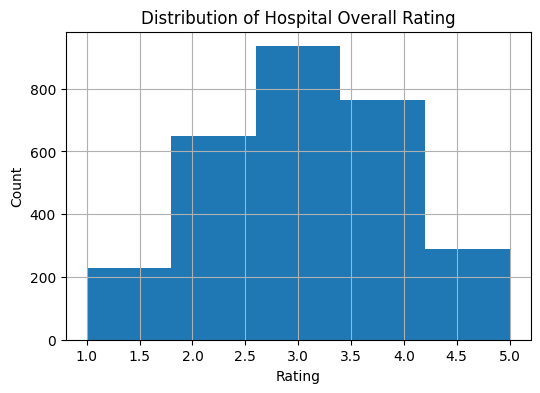

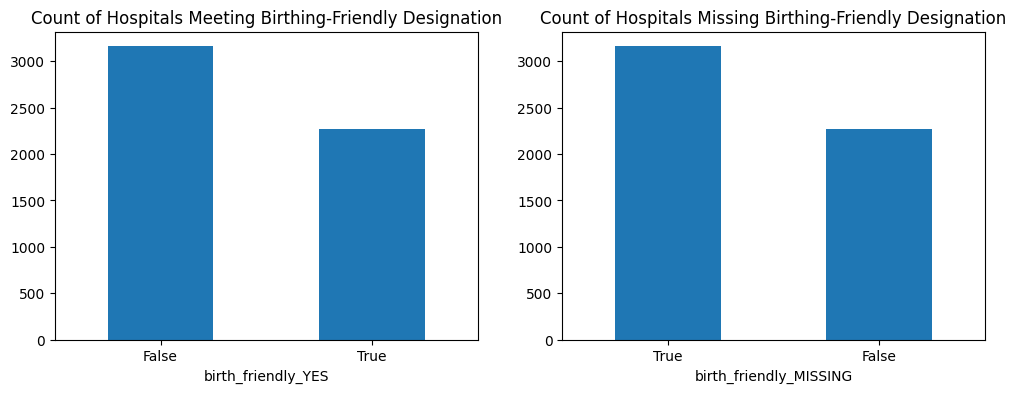

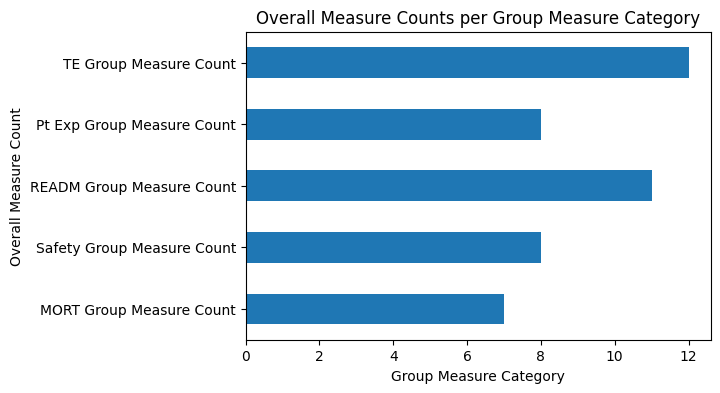

In [151]:
#Plot distributions of columns of interest

measure_counts = ['MORT Group Measure Count', 'Safety Group Measure Count', 
                  'READM Group Measure Count', 'Pt Exp Group Measure Count', 
                  'TE Group Measure Count']
cols_of_int = ['State', 'ZIP Code', 'Hospital Type', 'Hospital Ownership', 'Emergency Services',
       'Meets criteria for birthing friendly designation', 'Hospital overall rating', 
       'Count of Facility MORT Measures', 'Count of MORT Measures Better', 
       'Count of Facility Safety Measures', 'Count of Safety Measures Better', 
       'Count of Facility READM Measures', 'Count of READM Measures Better',
       'Count of Facility Pt Exp Measures', 'Count of Facility TE Measures',
       'MORT_fac_rate', 'MORT_bet_rate', 'Safety_fac_rate', 'Safety_bet_rate', 
       'READM_fac_rate', 'READM_bet_rate', 'PtExp_fac_rate', 'TE_fac_rate',
       'birth_friendly_YES', 'birth_friendly_MISSING']


#Plot overall rating and birthing

plt.figure(figsize=(6,4))
df['Hospital overall rating'].dropna().hist(bins=5)
plt.title("Distribution of Hospital Overall Rating")
plt.xlabel("Rating")
plt.ylabel("Count")


''' OLD CODE
#Plot Meets birthing-friendly designation
plt.figure(figsize=(6,4))
df['Meets criteria for birthing friendly designation'].value_counts().plot(kind='bar')
plt.title("Count of Hospitals Meeting Birthing-Friendly Designation")
plt.tick_params(rotation=0)
plt.show()
'''

#Plot Meets birthing-friendly designation
fig, axes = plt.subplots(1,2, figsize=(12,4))
axes = axes.ravel()

df['birth_friendly_YES'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title("Count of Hospitals Meeting Birthing-Friendly Designation")
axes[0].tick_params(rotation=0)

df['birth_friendly_MISSING'].value_counts().plot(kind='bar', ax=axes[1])
axes[1].set_title("Count of Hospitals Missing Birthing-Friendly Designation")
axes[1].tick_params(rotation=0)



#Plot number of measure counts per outcome
plt.figure(figsize=(6,4))
df[measure_counts].max().dropna().plot(kind='barh')
plt.title("Overall Measure Counts per Group Measure Category")
plt.xlabel("Group Measure Category")
plt.ylabel("Overall Measure Count")


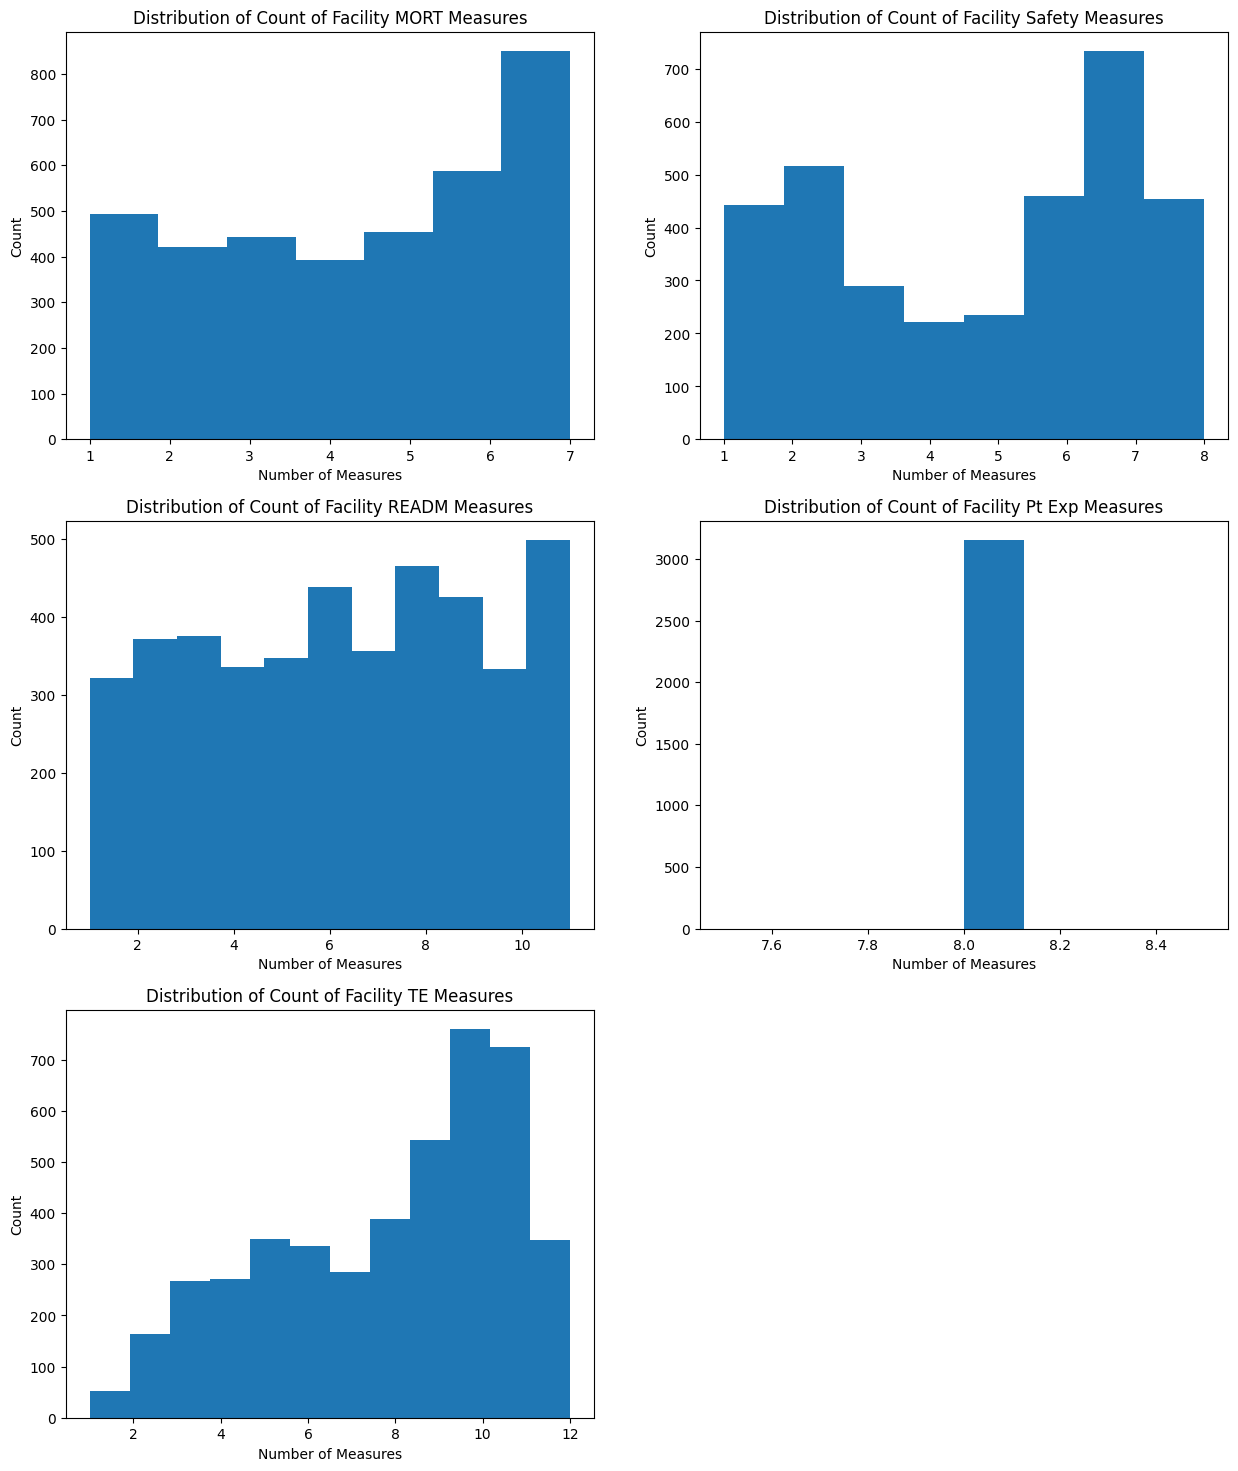

In [152]:
#Plot Facility measure counts for each category

fac_list = []
bet_list = []

for col in cols_of_int:
    if 'facility' in col.lower():
        fac_list.append(col)
    elif 'better' in col.lower():
        bet_list.append(col)



fig, axes = plt.subplots(3, 2, figsize=(15,18))
axes = axes.ravel()

for i,fac in enumerate(fac_list):
    axes[i].hist(df[fac].dropna(), bins=int(df[fac].dropna().max()))
    axes[i].set_title(f'Distribution of {fac}')
    axes[i].set_xlabel('Number of Measures')
    axes[i].set_ylabel('Count')
    #for mx in measure_counts:
    #    if fac.split()[-2] in mx:
    #        plt.axvline(int(df[mx].dropna().max()), linewidth=2, color='orange')
fig.delaxes(axes[5])

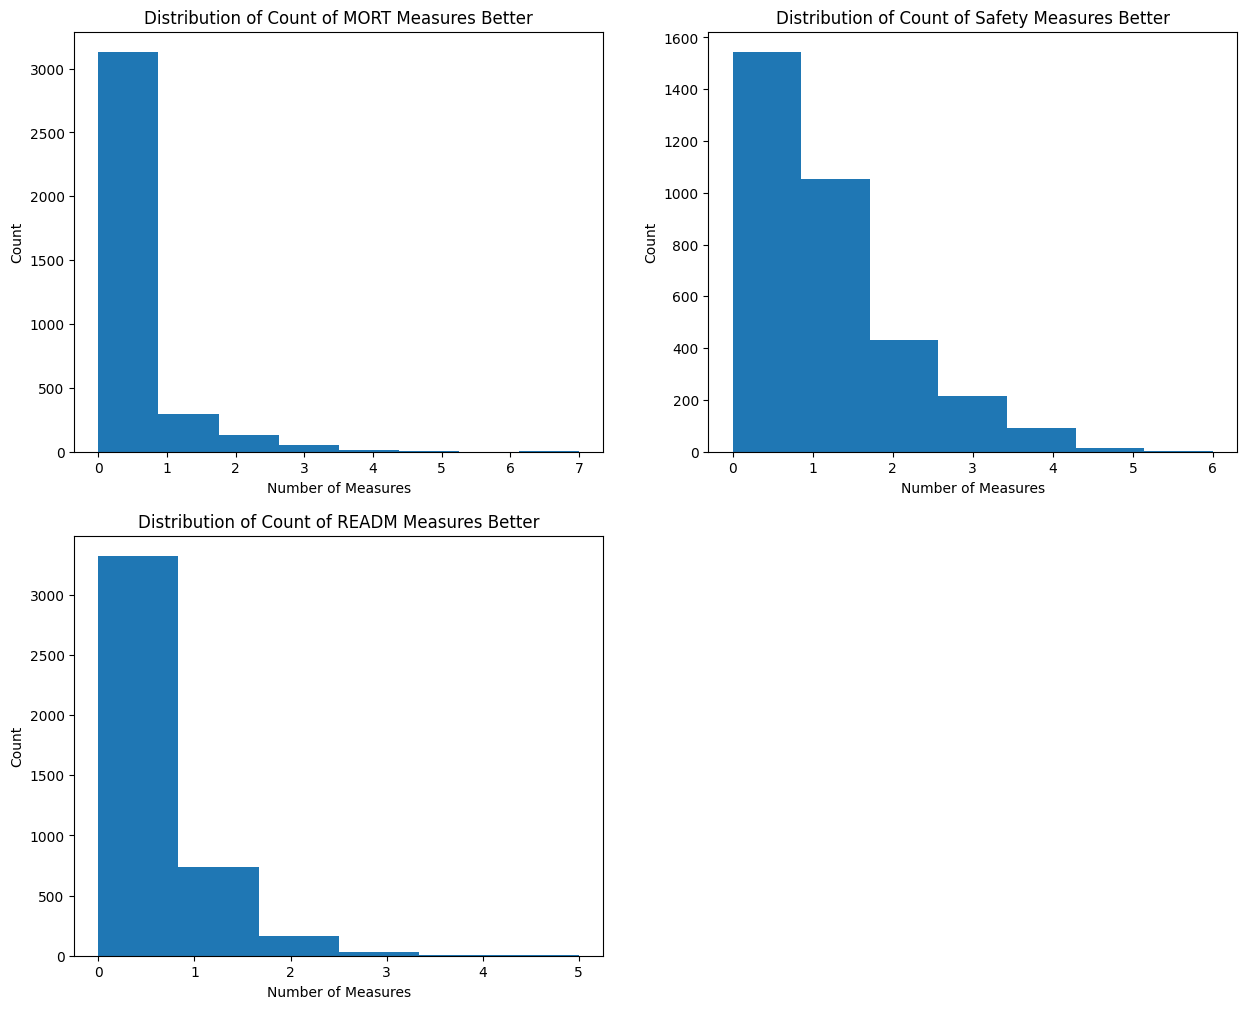

In [153]:
#Plot Facility measure "better" counts for each category

fig, axes = plt.subplots(2, 2, figsize=(15,12))
axes = axes.ravel()

for i,bet in enumerate(bet_list):
    axes[i].hist(df[bet].dropna(), bins=int(df[bet].dropna().max()+1))
    axes[i].set_title(f'Distribution of {bet}')
    axes[i].set_xlabel('Number of Measures')
    axes[i].set_ylabel('Count')

fig.delaxes(axes[3])

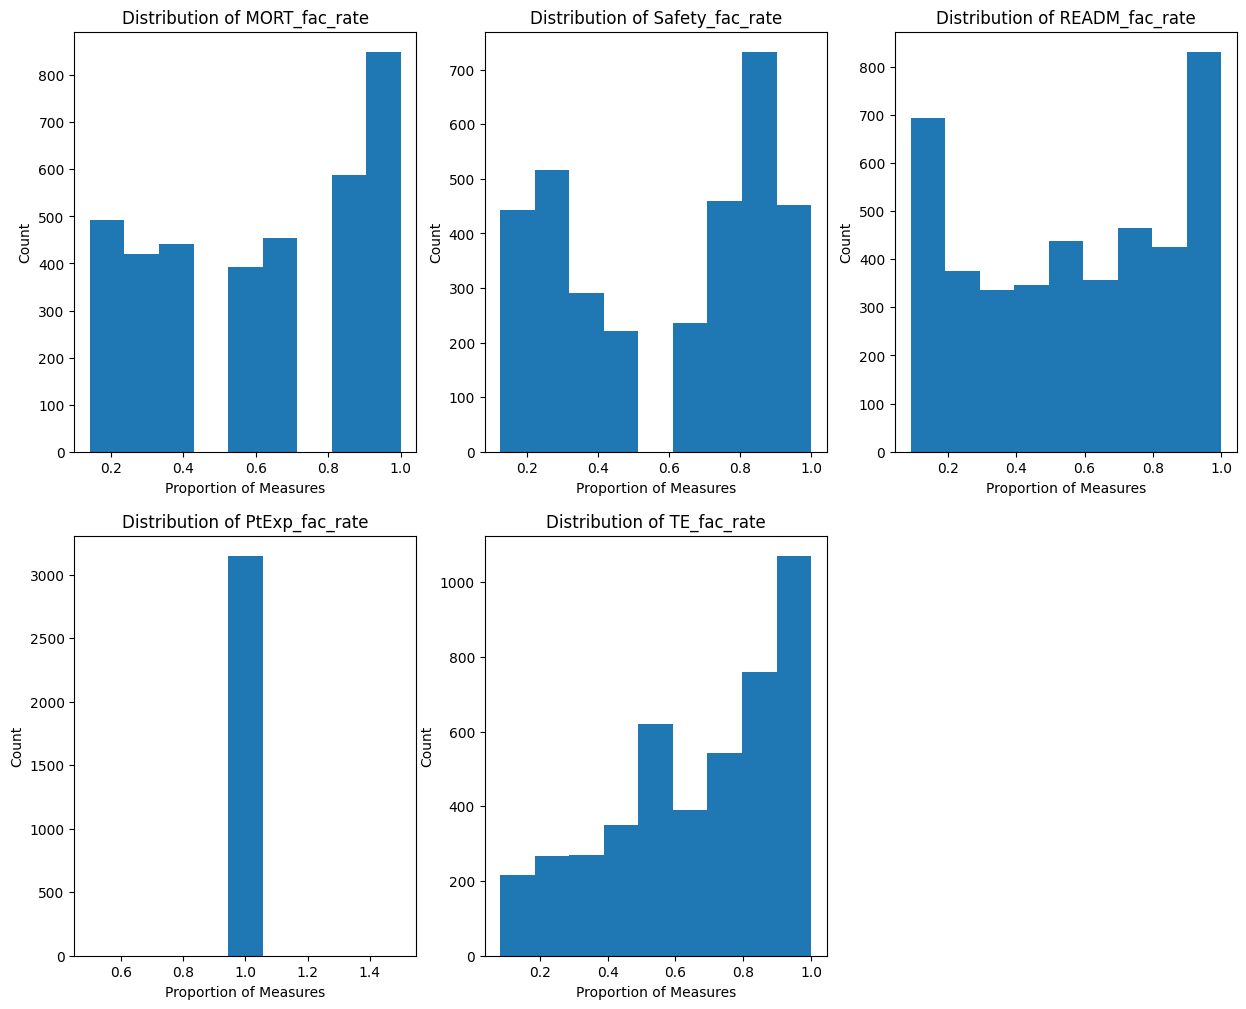

In [154]:
#Plot Facility measure count rates for each category

fac_rates = ['MORT_fac_rate', 'Safety_fac_rate', 'READM_fac_rate', 
             'PtExp_fac_rate', 'TE_fac_rate']
bet_rates = ['MORT_bet_rate', 'Safety_bet_rate', 'READM_bet_rate'] 

fig, axes = plt.subplots(2, 3, figsize=(15,12))
axes = axes.ravel()

for i,fac in enumerate(fac_rates):
    axes[i].hist(df[fac].dropna(), bins=int(df[fac].dropna().max()*10-1))
    axes[i].set_title(f'Distribution of {fac}')
    axes[i].set_xlabel('Proportion of Measures')
    axes[i].set_ylabel('Count')

fig.delaxes(axes[5])

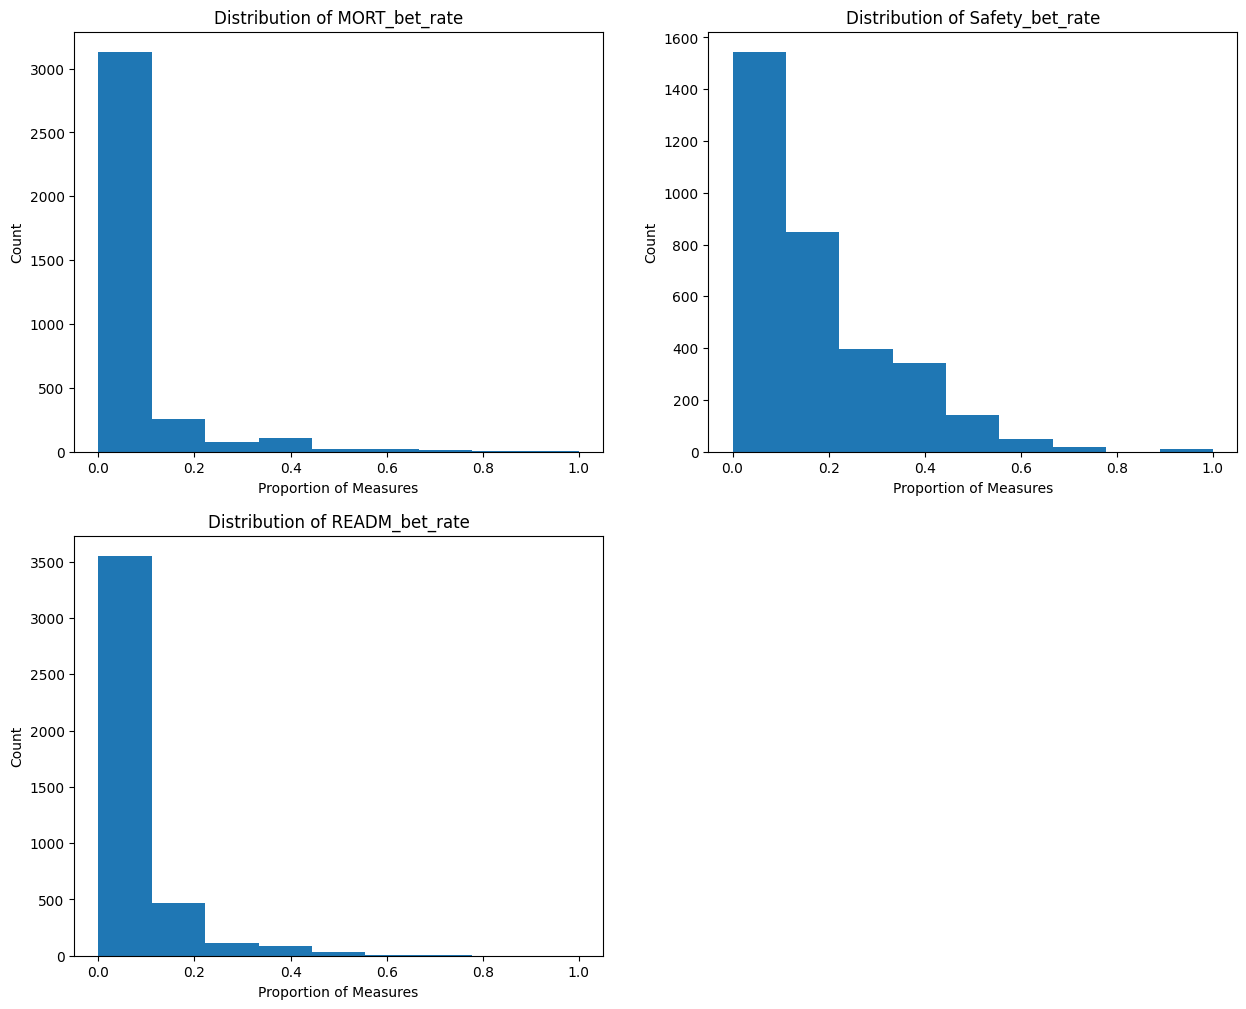

In [155]:
#Plot Facility measure count 'better' rates for each category

fig, axes = plt.subplots(2, 2, figsize=(15,12))
axes = axes.ravel()

for i,bet in enumerate(bet_rates):
    axes[i].hist(df[bet].dropna(), bins=int(df[bet].dropna().max()*10-1))
    axes[i].set_title(f'Distribution of {bet}')
    axes[i].set_xlabel('Proportion of Measures')
    axes[i].set_ylabel('Count')

fig.delaxes(axes[3])

<Figure size 700x400 with 0 Axes>

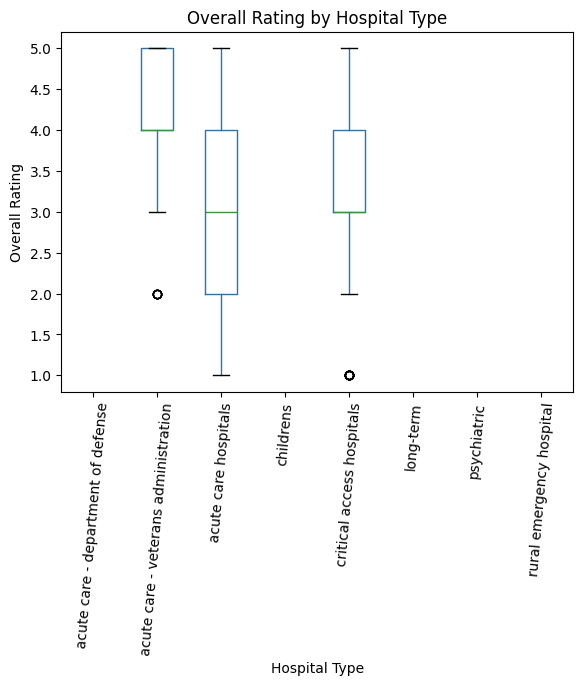

In [156]:
#Plot distribution of ratings by hospital type

plt.figure(figsize=(7, 4))

df.boxplot(column="Hospital overall rating", by="Hospital Type", grid=False)

plt.title("Overall Rating by Hospital Type")
plt.suptitle("")
plt.xlabel("Hospital Type")
plt.ylabel("Overall Rating")
plt.xticks(rotation=85)
plt.show()

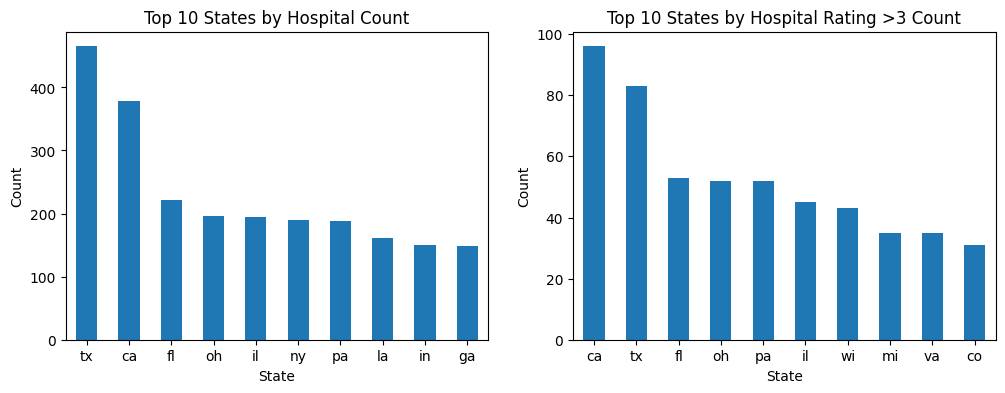

In [157]:
#Plot count of hospitals in the top 10 states

fig, axes = plt.subplots(1,2, figsize=(12, 4))
axes = axes.ravel()

hosp_counts_bystate = df["State"].value_counts(dropna=False).head(10)

hosp_counts_bystate.plot(kind="bar", ax=axes[0])
axes[0].set_title("Top 10 States by Hospital Count")
axes[0].set_xlabel("State")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=0)



#Plot count of hospitals with ratings >3 in the top 10 states

hosp_ratings_bystate = df[df["Hospital overall rating"] > 3]["State"].value_counts(dropna=False).head(10)

hosp_ratings_bystate.plot(kind="bar", ax=axes[1])
axes[1].set_title("Top 10 States by Hospital Rating >3 Count")
axes[1].set_xlabel("State")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=0)

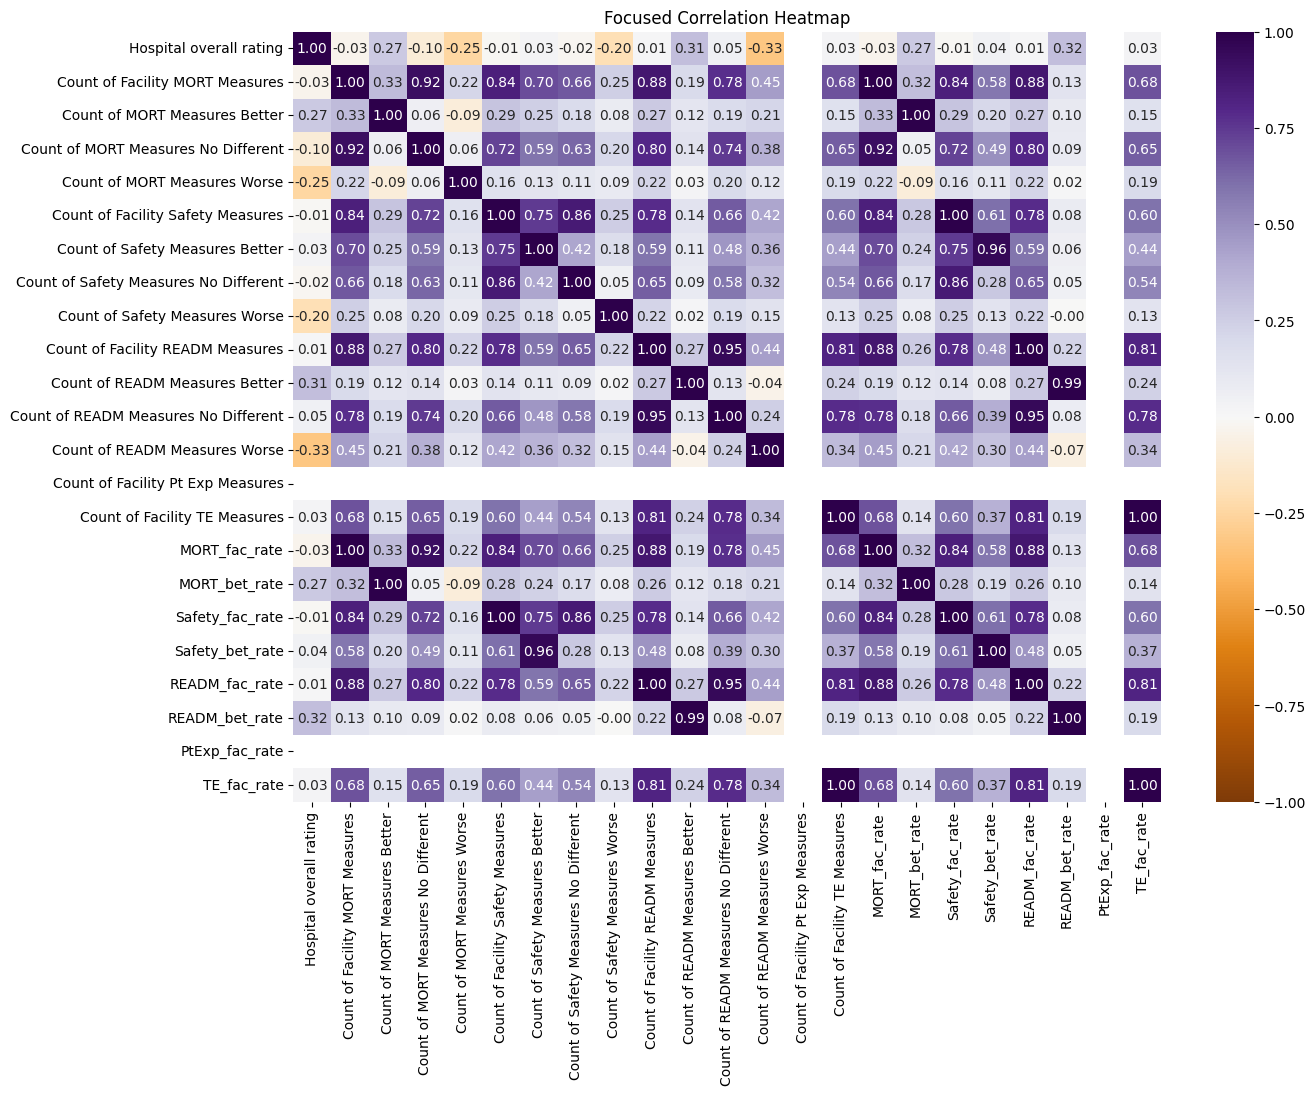

In [158]:
#Plot correlations for features, especially numerics but consider groupby for other categories to see if there is any heatmapping related to that.

meas_cols = ['MORT Group Measure Count', 'Safety Group Measure Count', 
             'READM Group Measure Count', 'Pt Exp Group Measure Count', 
             'TE Group Measure Count']  
num_cols = ['Hospital overall rating',  'Count of Facility MORT Measures',
            'Count of MORT Measures Better', 'Count of MORT Measures No Different', 
            'Count of MORT Measures Worse', 'Count of Facility Safety Measures',
            'Count of Safety Measures Better', 'Count of Safety Measures No Different',
            'Count of Safety Measures Worse', 'Count of Facility READM Measures',
            'Count of READM Measures Better', 'Count of READM Measures No Different', 
            'Count of READM Measures Worse',  'Count of Facility Pt Exp Measures', 
            'Count of Facility TE Measures', 'MORT_fac_rate', 'MORT_bet_rate',
            'Safety_fac_rate', 'Safety_bet_rate', 'READM_fac_rate', 'READM_bet_rate', 
            'PtExp_fac_rate', 'TE_fac_rate']
cat_cols = ['State', 'ZIP Code', 'Hospital Type', 'Hospital Ownership', 'Emergency Services',
       'birth_friendly_YES', 'birth_friendly_MISSING']
text_cols = ['Facility Name', 'Address', 'City/Town', 'County/Parish', 'Telephone Number', 
             'Hospital overall rating footnote', 'MORT Group Footnote', 'Safety Group Footnote',
             'READM Group Footnote', 'Pt Exp Group Footnote', 'TE Group Footnote']
id_cols = ['Facility ID',]


corr_mat_num = df[num_cols].corr(method="spearman")
corr_mat_cat = df[cat_cols]

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_mat_num,
    annot=True,
    fmt=".2f",
    cmap="PuOr",
    vmin=-1,
    vmax=1,
)
plt.title("Focused Correlation Heatmap")
#plt.tight_layout()
plt.show()

In [159]:
#Group ratings and hospital types--note only 3 hospital types present

df.groupby("Hospital overall rating")["Hospital Type"].value_counts(dropna=False)

Hospital overall rating  Hospital Type                       
1.0                      acute care hospitals                    213
                         critical access hospitals                16
2.0                      acute care hospitals                    607
                         critical access hospitals                36
                         acute care - veterans administration      6
3.0                      acute care hospitals                    831
                         critical access hospitals                84
                         acute care - veterans administration     20
4.0                      acute care hospitals                    673
                         critical access hospitals                60
                         acute care - veterans administration     32
5.0                      acute care hospitals                    216
                         acute care - veterans administration     55
                         critical access 

In [160]:
df['Emergency Services'].value_counts()

Emergency Services
True     4499
False     927
Name: count, dtype: int64

# Data Validation Check for Data Cleaning

In [ ]:
#Pull in raw data for comparison to data exploration

df_new = pd.read_excel('data/raw/Hospital_General_Info.xlsx')

print(df_new['Emergency Services'].value_counts())
print('The number of missing values is:', df_new['Emergency Services'].isna().sum(), '\n')

print(df_new['Meets criteria for birthing friendly designation'].value_counts())
print('The number of missing values is:', df_new['Meets criteria for birthing friendly designation'].isna().sum())

Emergency Services
Yes    4499
No      927
Name: count, dtype: int64
The number of missing values is: 0 

Meets criteria for birthing friendly designation
Y    2265
Name: count, dtype: int64
The number of missing values is: 3161


In [ ]:
# Explore missing values further--remove Hospital Types without ratings 
# to dial in missingness further, creating new df2

df2 = df_new[
    df_new["Hospital Type"].str.casefold().isin([
        "acute care hospitals",
        "critical access hospitals",
        "acute care - veterans administration",
    ])
].copy()

In [124]:
# Explore missingness in Meets criteria for birthing friendly designation column 
# as the missingness here may not be random based on listed hospital types. 
# Originally encoded this as boolean True/False.

print('The proportion of missing values in Meets criteria for birthing friendly ' 
      'designation is:', df2['Meets criteria for birthing friendly designation'].isna().mean())
print('The sum of missing values in Hospital overall rating is:', df2['Hospital overall rating'].isna().sum())
print('The total number of facilities remaining is:', len(df2))

The proportion of missing values in Meets criteria for birthing friendly designation is: 0.5101643598615917
The sum of missing values in Hospital overall rating is: 0
The total number of facilities remaining is: 4624


In [125]:
# Dive deeper into missingness for Meets criteria for birthing friendly 
# designation--proportion of missingness for each hospital type

miss = df2['Meets criteria for birthing friendly designation'].isna()
pd.crosstab(df2["Hospital Type"], miss, normalize="index")

Meets criteria for birthing friendly designation,False,True
Hospital Type,,
Acute Care - Veterans Administration,0.000000,1.000000
Acute Care Hospitals,0.657895,0.342105
Critical Access Hospitals,0.156250,0.843750


In [126]:
# Dive deeper into missingness for Meets criteria for birthing friendly 
# designation--proportion of missingness for each state

miss = df2['Meets criteria for birthing friendly designation'].isna()
pd.crosstab(df2["State"], miss, normalize="index")

Meets criteria for birthing friendly designation,False,True
State,,
AK,0.523810,0.476190
AL,0.431818,0.568182
AR,0.424658,0.575342
AS,0.000000,1.000000
AZ,0.464286,0.535714
CA,0.597523,0.402477
CO,0.529412,0.470588
CT,0.821429,0.178571
DC,0.714286,0.285714


In [ ]:
# Dive deeper into missingness for Meets criteria for birthing friendly 
# designation--stats compared hospital rating

print(
    df.assign(birth_missing=miss)
      .groupby("birth_missing")["Hospital overall rating"]
      .describe()
)

                count      mean       std  min  25%  50%  75%  max
birth_missing                                                     
False          2016.0  3.053075  1.063101  1.0  2.0  3.0  4.0  5.0
True            850.0  3.149412  1.178940  1.0  2.0  3.0  4.0  5.0


From these observations, the missingness of the Meets criteria for birthing friendly is *NOT* random. Therefore, this should not be boolean coded and should be better represented in the data in cleaning. Consider converting original column into broken out columns to better represent the missingness (similar to OHE?).